# Hotel Booking Demand — End-to-End Exploratory Data Analysis

**`Notebook structure`**
1. Setup & Imports
2. Data Loading
3. Initial Inspection
4. Data Quality Assessment
5. Data Cleaning
6. Feature Engineering
7. Univariate Analysis
8. Bivariate Analysis
9. Multivariate / Correlation Analysis
10. Time-Series & Seasonality Analysis
11. Business Problem 1 — Cancellation Drivers & Risk Flagging
13. Business Problem 3 — Seasonal Demand & Pricing
15. Business Problem 4 — Room Allocation Mismatches
16. Business Problem 5 — Repeat Guest / Loyalty Value

## 1: Importing Libraries

In [3]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 2. Data Loading

Load the raw CSV. Keep a pristine copy (`df_raw`) untouched, and work on a copy (`df`) from here on —
this is standard practice so we can always diff our cleaning steps against the original.

In [4]:
DATA_PATH = "hotel_bookings.csv"

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.head()

Rows: 119,390  |  Columns: 32


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 3: Initial Inspection

In [5]:
df.head(4)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02


In [6]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [8]:
df.describe(include='all')

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
count,119390,119390.000000,119390.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,...,119390,103050.000000,6797.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390,119390
unique,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,...,3,NaN,NaN,NaN,4,NaN,NaN,NaN,3,926
top,City Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,...,No Deposit,NaN,NaN,NaN,Transient,NaN,NaN,NaN,Check-Out,2015-10-21
freq,79330,NaN,NaN,NaN,13877,NaN,NaN,NaN,NaN,NaN,...,104641,NaN,NaN,NaN,89613,NaN,NaN,NaN,75166,1461
mean,NaN,0.370416,104.011416,2016.156554,NaN,27.165173,15.798241,0.927599,2.500302,1.856403,...,NaN,86.693382,189.266735,2.321149,NaN,101.831122,0.062518,0.571363,NaN,NaN
std,NaN,0.482918,106.863097,0.707476,NaN,13.605138,8.780829,0.998613,1.908286,0.579261,...,NaN,110.774548,131.655015,17.594721,NaN,50.535790,0.245291,0.792798,NaN,NaN
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,...,NaN,1.000000,6.000000,0.000000,NaN,-6.380000,0.000000,0.000000,NaN,NaN
25%,NaN,0.000000,18.000000,2016.000000,NaN,16.000000,8.000000,0.000000,1.000000,2.000000,...,NaN,9.000000,62.000000,0.000000,NaN,69.290000,0.000000,0.000000,NaN,NaN
50%,NaN,0.000000,69.000000,2016.000000,NaN,28.000000,16.000000,1.000000,2.000000,2.000000,...,NaN,14.000000,179.000000,0.000000,NaN,94.575000,0.000000,0.000000,NaN,NaN
75%,NaN,1.000000,160.000000,2017.000000,NaN,38.000000,23.000000,2.000000,3.000000,2.000000,...,NaN,229.000000,270.000000,0.000000,NaN,126.000000,0.000000,1.000000,NaN,NaN


## Step 4: DATA Quality Assessment

In [9]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_report = missing_report[missing_report["missing_count"] > 0].sort_values("missing_pct", ascending=False)
missing_report # This will give us only those Columns who have > 0 null values

,missing_count,missing_pct
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


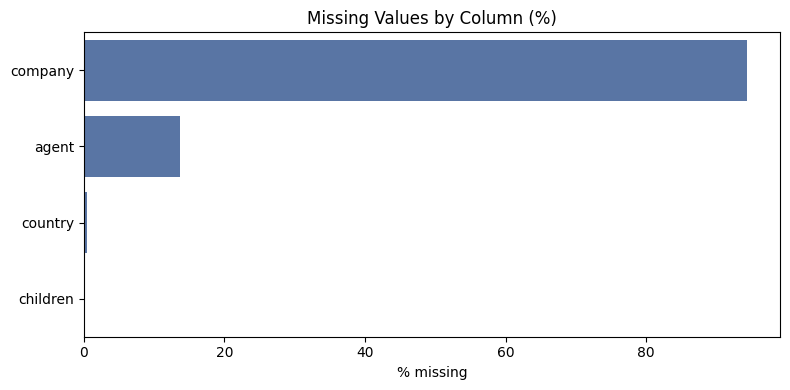

In [10]:
plt.figure(figsize=(8, 4))
sns.barplot(x=missing_report["missing_pct"], y=missing_report.index, color="#4C72B0")
plt.title("Missing Values by Column (%)")
plt.xlabel("% missing")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [11]:
dupe_count = df.duplicated().sum()
print(f"Fully duplicated rows: {dupe_count:,} ({dupe_count/len(df)*100:.1f}% of dataset)")

Fully duplicated rows: 31,994 (26.8% of dataset)


In [12]:
# Sanity checks for logically impossible records
zero_guest_bookings = df[(df["adults"] + df["children"].fillna(0) + df["babies"]) == 0]
print(f"Bookings with zero total guests (likely data errors): {len(zero_guest_bookings):,}")

print(f"\nADR distribution check (top 5 highest values):")
print(df["adr"].sort_values(ascending=False).head(5).to_string())

Bookings with zero total guests (likely data errors): 180

ADR distribution check (top 5 highest values):
48515     5400.0
111403     510.0
15083      508.0
103912     451.5
13142      450.0


**Findings so far:**
- `company` is missing for the vast majority of bookings, `agent` for a meaningful minority — both are
  reference IDs, not measurements, so imputing them numerically would be meaningless.
- A modest number of duplicate rows exist — common in booking-system exports and worth deciding on
  a case-by-case basis whether to deduplicate (we will, for most aggregate analyses).
- A small number of "zero guest" bookings and one **extreme `adr` outlier** stand out immediately —
  classic hallmark of manual data-entry errors that must be handled before any pricing analysis.

## 5. DATA Cleaning

In [13]:
df_clean = df.copy()

# --- 5.1 Fix dtypes: these are counts/IDs, not continuous floats ---
df_clean["children"] = df_clean["children"].fillna(0).astype(int)
df_clean["agent"] = df_clean["agent"]      # keep as float (NaN = no agent), but flag usage below
df_clean["company"] = df_clean["company"]  # keep as float (NaN = no company), but flag usage below

df_clean["has_agent"] = df_clean["agent"].notna().astype(int)
df_clean["has_company"] = df_clean["company"].notna().astype(int)

# --- 5.2 Handle missing country: impute with 'Unknown' rather than dropping ---
df_clean["country"] = df_clean["country"].fillna("Unknown")

# --- 5.3 Remove logically invalid rows: bookings with zero total guests ---
before = len(df_clean)
df_clean = df_clean[(df_clean["adults"] + df_clean["children"] + df_clean["babies"]) > 0]
print(f"Dropped {before - len(df_clean):,} zero-guest rows")

# --- 5.4 Treat the extreme ADR outlier (known data-entry error) ---
before = len(df_clean)
adr_cap = df_clean["adr"].quantile(0.999)
outliers = df_clean[df_clean["adr"] > adr_cap]
print(f"Capping {len(outliers)} extreme ADR outlier(s) above the 99.9th percentile (~{adr_cap:.2f})")
df_clean = df_clean[df_clean["adr"] <= adr_cap]

# --- 5.5 Remove exact duplicate rows for aggregate/statistical analysis ---
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Dropped {before - len(df_clean):,} duplicate rows")

# --- 5.6 Build a proper arrival_date datetime column ---
month_map = {m: i+1 for i, m in enumerate(
    ["January","February","March","April","May","June","July","August",
     "September","October","November","December"])}
df_clean["arrival_month_num"] = df_clean["arrival_date_month"].map(month_map)
df_clean["arrival_date"] = pd.to_datetime(dict(
    year=df_clean["arrival_date_year"],
    month=df_clean["arrival_month_num"],
    day=df_clean["arrival_date_day_of_month"]
), errors="coerce")

df_clean["reservation_status_date"] = pd.to_datetime(df_clean["reservation_status_date"], errors="coerce")

print(f"\nFinal cleaned shape: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")


Dropped 180 zero-guest rows
Capping 120 extreme ADR outlier(s) above the 99.9th percentile (~326.26)
Dropped 31,979 duplicate rows

Final cleaned shape: 87,111 rows x 36 columns


In [14]:
# Confirm cleanliness
print("Remaining missing values:\n", df_clean.isna().sum()[df_clean.isna().sum() > 0])
print("\nRemaining duplicates:", df_clean.duplicated().sum())

Remaining missing values:
 agent      12126
company    81874
dtype: int64

Remaining duplicates: 0


## 6. Feature Engineering

We derive a handful of business-meaningful features that don't exist directly in the raw data but are
essential for the analyses ahead (total stay length, realized revenue, room mismatch flag, etc.).

In [15]:
fe = df_clean.copy()

fe["total_nights"] = fe["stays_in_weekend_nights"] + fe["stays_in_week_nights"]
fe["total_guests"] = fe["adults"] + fe["children"] + fe["babies"]
fe["revenue"] = fe["adr"] * fe["total_nights"]
fe["room_mismatch"] = (fe["reserved_room_type"] != fe["assigned_room_type"]).astype(int)
fe["is_family"] = ((fe["children"] > 0) | (fe["babies"] > 0)).astype(int)

def get_season(month_num):
    if month_num in [12, 1, 2]:
        return "Winter"
    elif month_num in [3, 4, 5]:
        return "Spring"
    elif month_num in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

fe["season"] = fe["arrival_month_num"].apply(get_season)
fe["lead_time_bucket"] = pd.cut(
    fe["lead_time"], bins=[-1, 7, 30, 90, 365, 10000],
    labels=["0-7 days", "8-30 days", "31-90 days", "91-365 days", "365+ days"]
)

df_final = fe
print("New features added:", [c for c in df_final.columns if c not in df_clean.columns])
df_final[["total_nights", "total_guests", "revenue", "room_mismatch", "is_family",
          "season", "lead_time_bucket"]].head()


New features added: ['total_nights', 'total_guests', 'revenue', 'room_mismatch', 'is_family', 'season', 'lead_time_bucket']


,total_nights,total_guests,revenue,room_mismatch,is_family,season,lead_time_bucket
0,0,2,0.0,0,0,Summer,91-365 days
1,0,2,0.0,0,0,Summer,365+ days
2,1,1,75.0,1,0,Summer,0-7 days
3,1,1,75.0,0,0,Summer,8-30 days
4,2,2,196.0,0,0,Summer,8-30 days


## 7. Univariate Analysis

Understanding each variable in isolation first — distribution shape, class balance, and obvious skew —
before looking at relationships between variables.

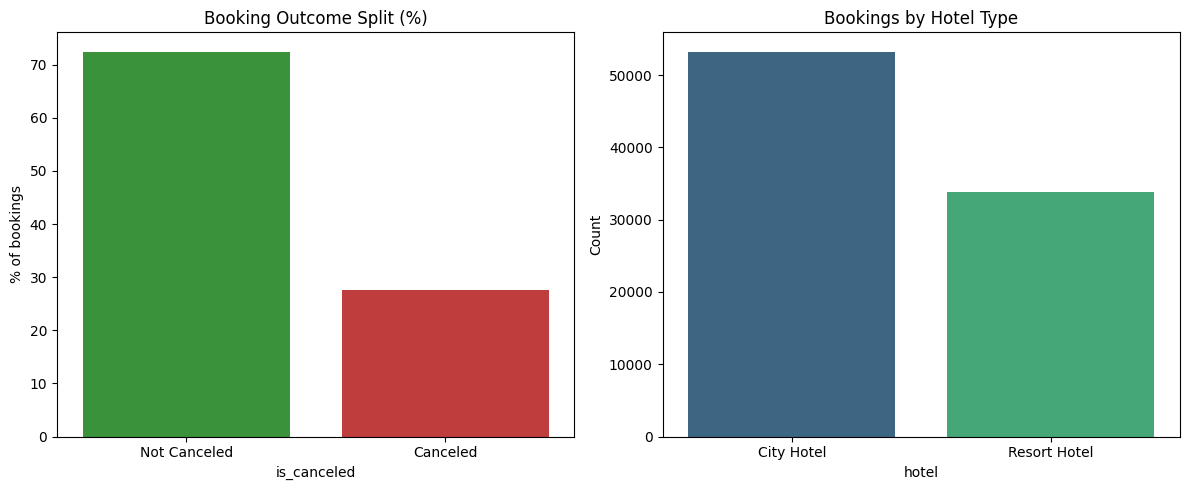

Overall cancellation rate: 27.5%


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cancel_counts = df_final["is_canceled"].value_counts(normalize=True) * 100
sns.barplot(x=cancel_counts.index.map({0: "Not Canceled", 1: "Canceled"}),
            y=cancel_counts.values, ax=axes[0], hue=cancel_counts.index.map({0: "Not Canceled", 1: "Canceled"}), legend=False, 
            palette=["#2ca02c", "#d62728"])

axes[0].set_title("Booking Outcome Split (%)")
axes[0].set_ylabel("% of bookings")

hotel_counts = df_final["hotel"].value_counts()
sns.barplot(x=hotel_counts.index, y=hotel_counts.values, ax=axes[1], hue=hotel_counts.index,legend=False, palette="viridis")
axes[1].set_title("Bookings by Hotel Type")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()

print(f"Overall cancellation rate: {df_final['is_canceled'].mean()*100:.1f}%")

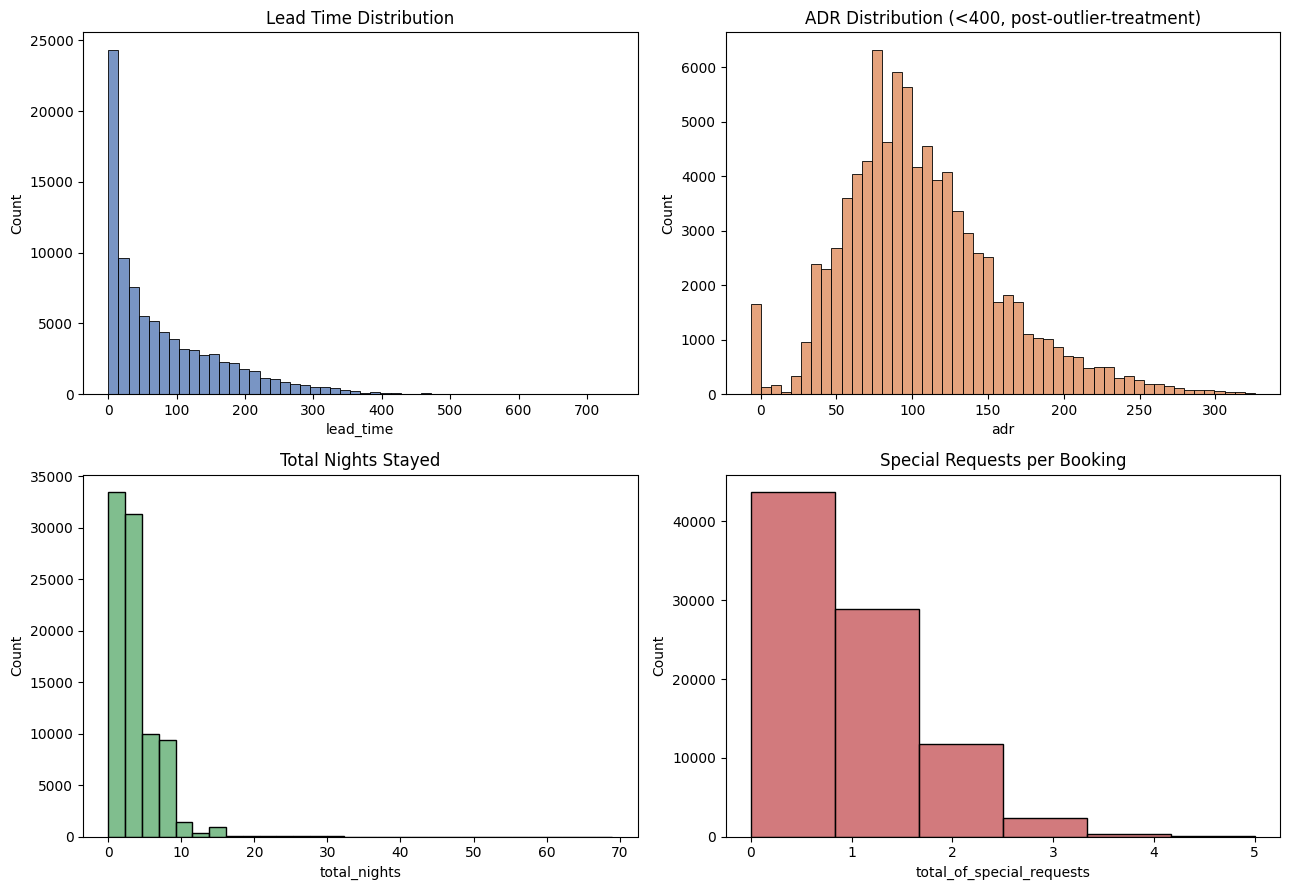

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(df_final["lead_time"], bins=50, ax=axes[0,0], color="#4C72B0")
axes[0,0].set_title("Lead Time Distribution")

sns.histplot(df_final[df_final["adr"] < 400]["adr"], bins=50, ax=axes[0,1], color="#DD8452")
axes[0,1].set_title("ADR Distribution (<400, post-outlier-treatment)")

sns.histplot(df_final["total_nights"], bins=30, ax=axes[1,0], color="#55A868")
axes[1,0].set_title("Total Nights Stayed")

sns.histplot(df_final["total_of_special_requests"], bins=6, ax=axes[1,1], color="#C44E52")
axes[1,1].set_title("Special Requests per Booking")

plt.tight_layout()
plt.show()


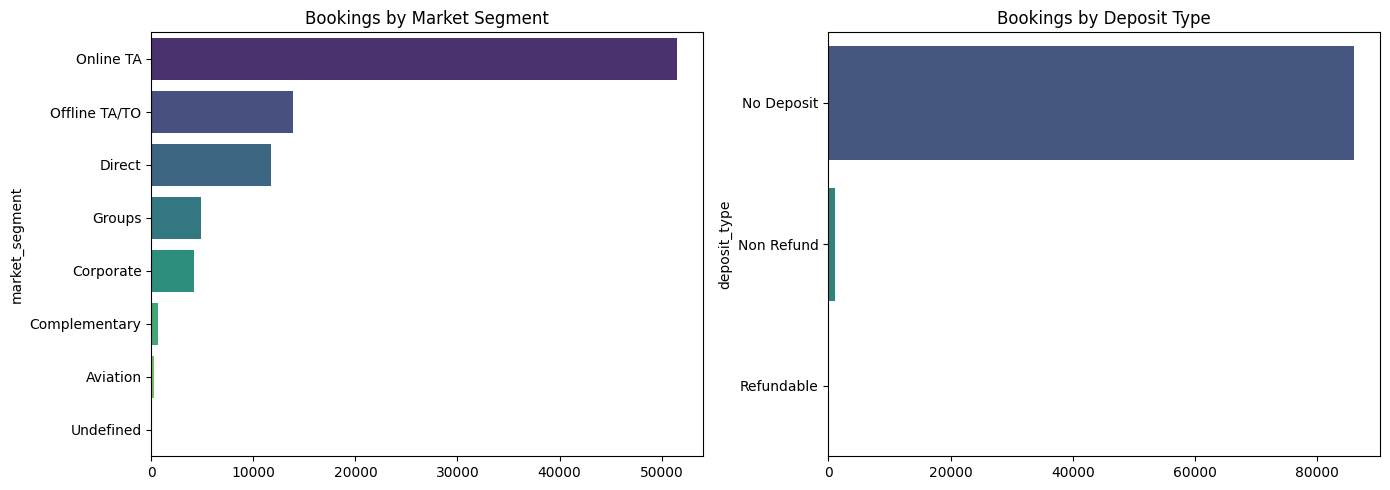

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seg_counts = df_final["market_segment"].value_counts()
sns.barplot(x=seg_counts.values, y=seg_counts.index, ax=axes[0],hue = seg_counts.index, palette="viridis")
axes[0].set_title("Bookings by Market Segment")

deposit_counts = df_final["deposit_type"].value_counts()
sns.barplot(x=deposit_counts.values, y=deposit_counts.index, ax=axes[1],hue = deposit_counts.index, palette="viridis")
axes[1].set_title("Bookings by Deposit Type")

plt.tight_layout()
plt.show()

**`Univariate takeaways:`**
- The dataset is moderately imbalanced toward non-cancellations, but cancellations are still a large
  enough minority (~30-40% territory) to be a serious revenue concern, not a rare edge case.
- Lead time is right-skewed — most guests book within a few months, but a long tail books almost two
  years out.
- The overwhelming majority of bookings carry **`No Deposit`**, which is important context for the
  cancellation analysis ahead.

## 8. Bivariate Analysis

Now we start connecting variables — specifically, what moves the two metrics the business cares about
most: **`cancellation likelihood`** and **`ADR (price realized)`**.

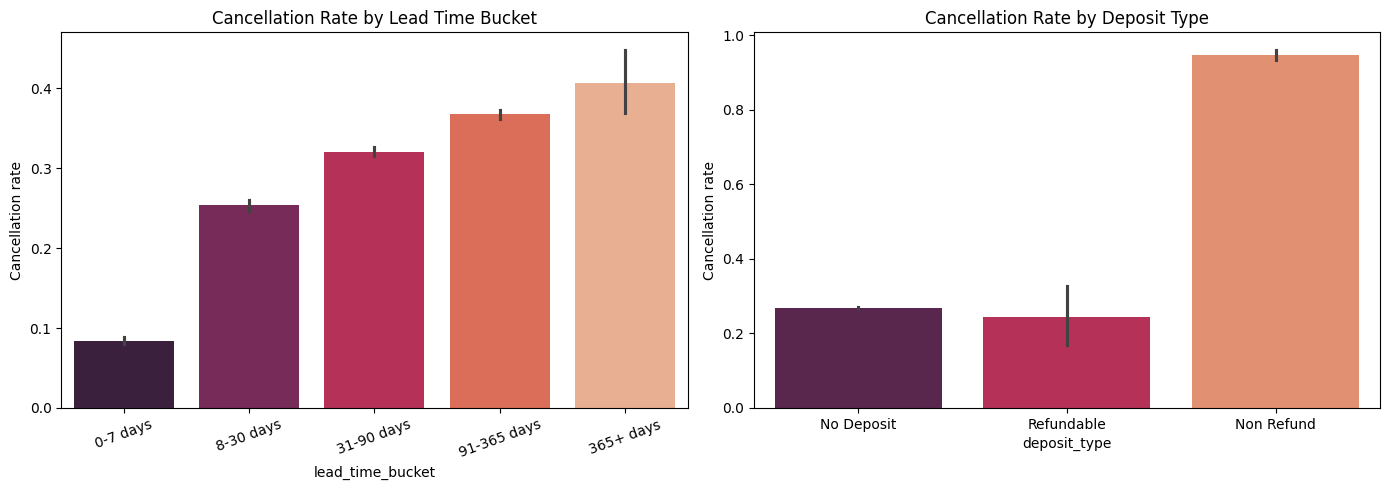

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df_final, x="lead_time_bucket", y="is_canceled", ax=axes[0], palette="rocket", hue="lead_time_bucket",legend=False)
axes[0].set_title("Cancellation Rate by Lead Time Bucket")
axes[0].set_ylabel("Cancellation rate")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=df_final, x="deposit_type", y="is_canceled", ax=axes[1], palette="rocket", hue="deposit_type",legend=False)
axes[1].set_title("Cancellation Rate by Deposit Type")
axes[1].set_ylabel("Cancellation rate")

plt.tight_layout()
plt.show()


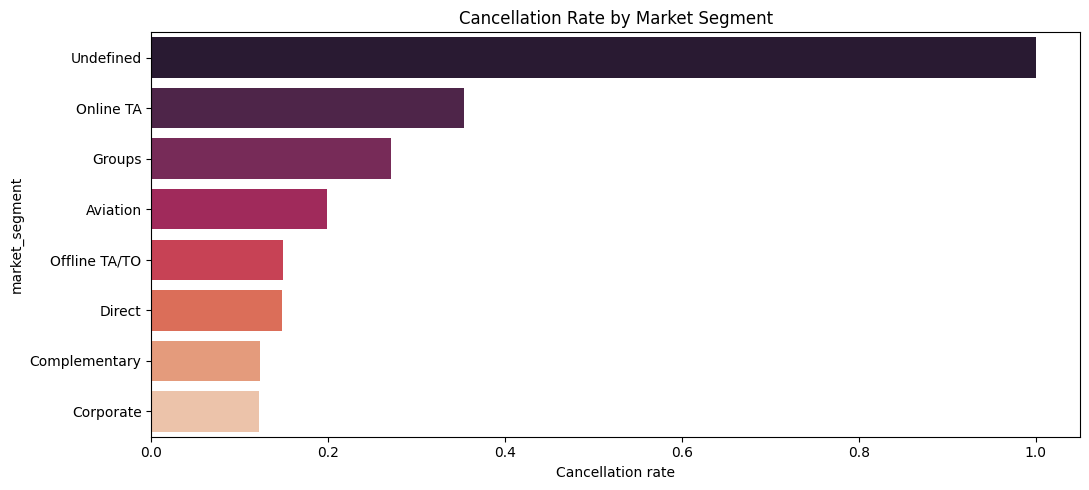

In [26]:
plt.figure(figsize=(11, 5))
seg_cancel = df_final.groupby("market_segment")["is_canceled"].mean().sort_values(ascending=False)
sns.barplot(x=seg_cancel.values, y=seg_cancel.index, palette="rocket",hue=seg_cancel.index,legend=False)
plt.title("Cancellation Rate by Market Segment")
plt.xlabel("Cancellation rate")
plt.tight_layout()
plt.show()

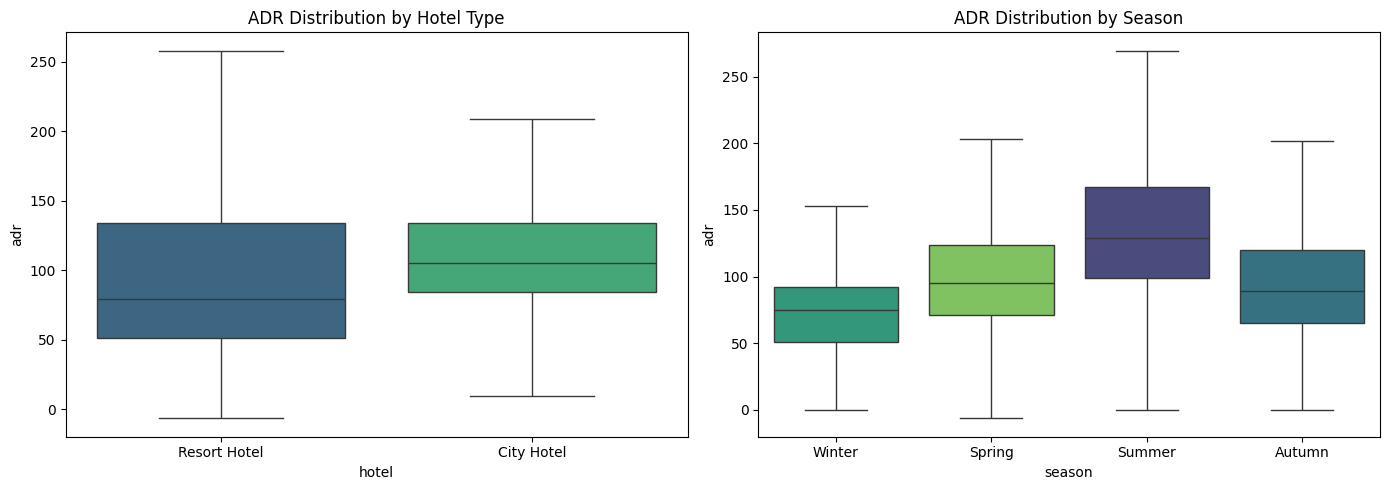

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_final, x="hotel", y="adr", ax=axes[0],hue="hotel",legend=False, showfliers=False, palette="viridis")
axes[0].set_title("ADR Distribution by Hotel Type")

sns.boxplot(data=df_final, x="season", y="adr", order=["Winter","Spring","Summer","Autumn"],
            ax=axes[1], hue="season", legend=False, showfliers=False, palette="viridis")
axes[1].set_title("ADR Distribution by Season")

plt.tight_layout()
plt.show()

**Bivariate takeaways:**
- Cancellation rate rises sharply as lead time increases — the earlier someone books relative to
  arrival, the more time/opportunity they have to change plans.
- `Non Refund` bookings show a *counter-intuitively higher* cancellation rate than `No Deposit` —
  worth flagging as a data-quality/fraud-pattern question, since one would expect a non-refundable
  deposit to *discourage* cancellation.
- Groups and Online TA segments cancel noticeably more than Direct and Corporate.
- ADR is higher for City Hotel and peaks in summer — consistent with leisure-driven seasonal demand.

## 9. Multivariate & Correlation Analysis

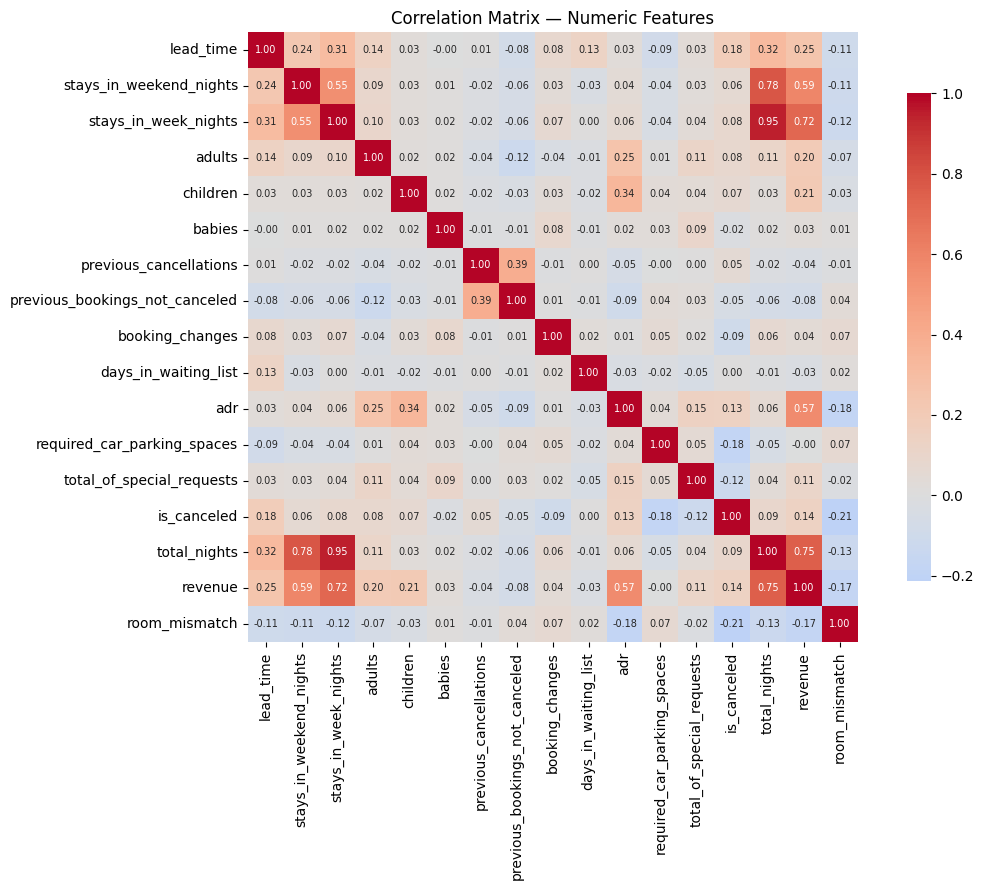

In [29]:
numeric_cols = ["lead_time", "stays_in_weekend_nights", "stays_in_week_nights", "adults",
                "children", "babies", "previous_cancellations", "previous_bookings_not_canceled",
                "booking_changes", "days_in_waiting_list", "adr", "required_car_parking_spaces",
                "total_of_special_requests", "is_canceled", "total_nights", "revenue", "room_mismatch"]

corr = df_final[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.8}, annot_kws={"size": 7})
plt.title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()

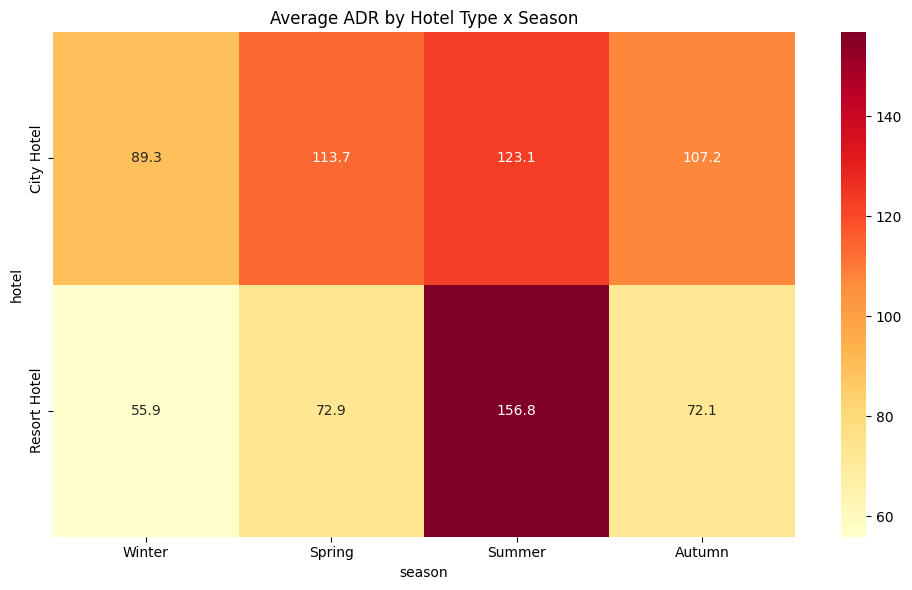

In [30]:
plt.figure(figsize=(10, 6))
pivot = df_final.pivot_table(index="hotel", columns="season", values="adr", aggfunc="mean")
pivot = pivot[["Winter","Spring","Summer","Autumn"]]
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title("Average ADR by Hotel Type x Season")
plt.tight_layout()
plt.show()

**Multivariate takeaways:**
- No single feature dominates cancellation risk in isolation — it's a combination of lead time,
  deposit type, and market segment, which is exactly why a simple multi-factor rule (or lightweight
  model) is more useful operationally than any one chart.
- The hotel × season ADR heatmap makes the pricing opportunity visually obvious: certain hotel/season
  combinations command a real premium that others don't yet fully capture.

## 10. Time-Series & Seasonality Analysis

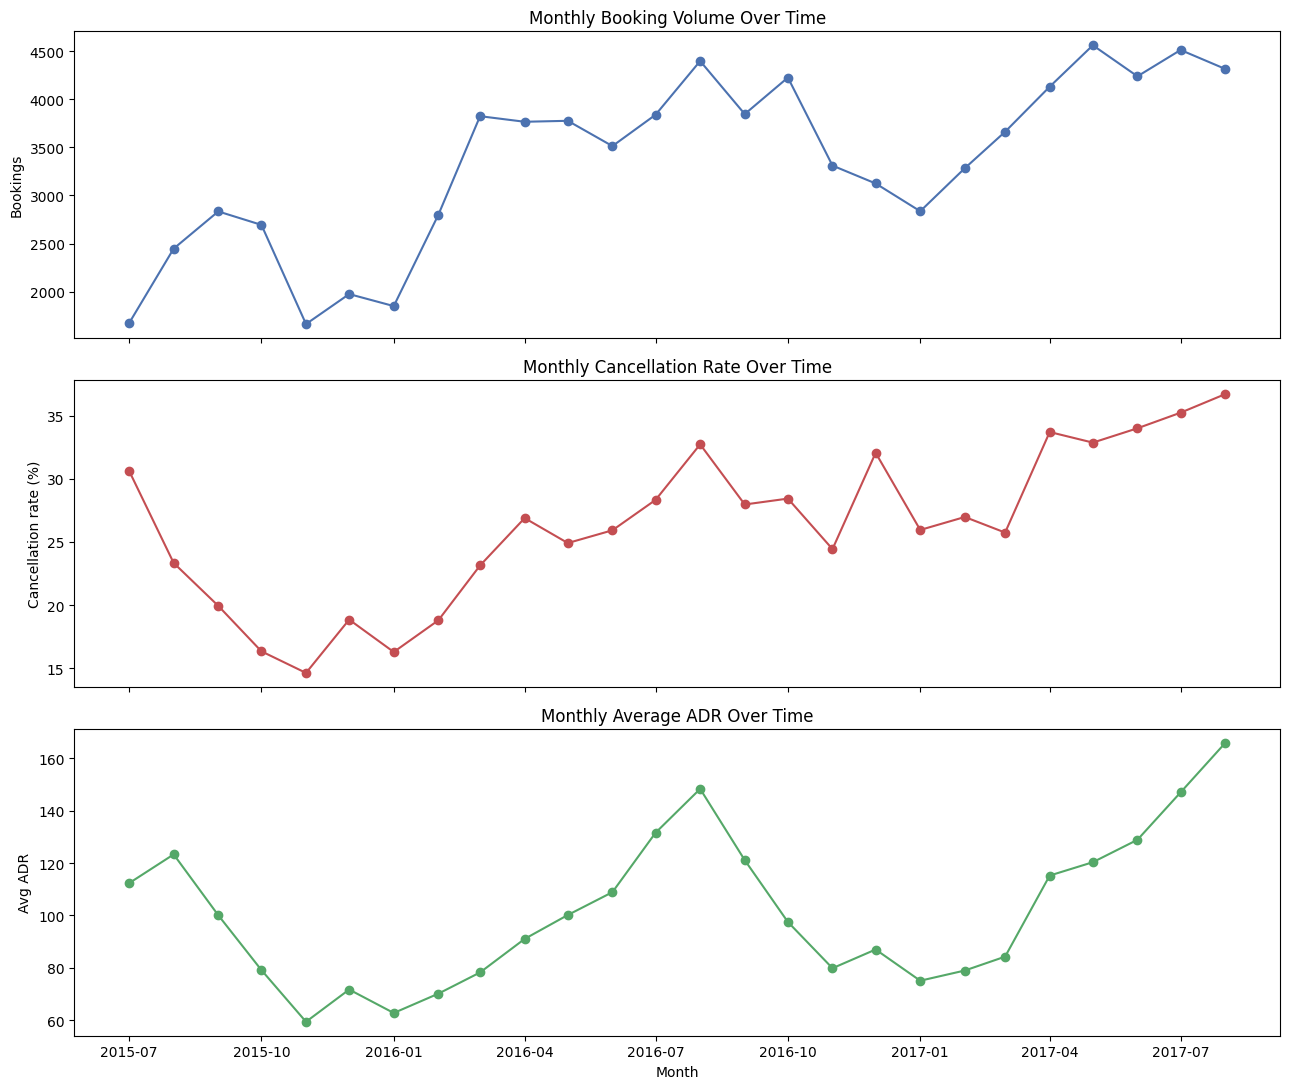

In [35]:
monthly = (df_final
           .groupby(["arrival_date_year", "arrival_month_num"])
           .agg(bookings=("hotel", "count"), cancel_rate=("is_canceled", "mean"), avg_adr=("adr", "mean"))
           .reset_index())
monthly["period"] = pd.to_datetime(dict(year=monthly["arrival_date_year"], month=monthly["arrival_month_num"], day=1))
monthly = monthly.sort_values("period")

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

axes[0].plot(monthly["period"], monthly["bookings"], marker="o", color="#4C72B0")
axes[0].set_title("Monthly Booking Volume Over Time")
axes[0].set_ylabel("Bookings")

axes[1].plot(monthly["period"], monthly["cancel_rate"]*100, marker="o", color="#C44E52")
axes[1].set_title("Monthly Cancellation Rate Over Time")
axes[1].set_ylabel("Cancellation rate (%)")

axes[2].plot(monthly["period"], monthly["avg_adr"], marker="o", color="#55A868")
axes[2].set_title("Monthly Average ADR Over Time")
axes[2].set_ylabel("Avg ADR")
axes[2].set_xlabel("Month")

plt.tight_layout()
plt.show()

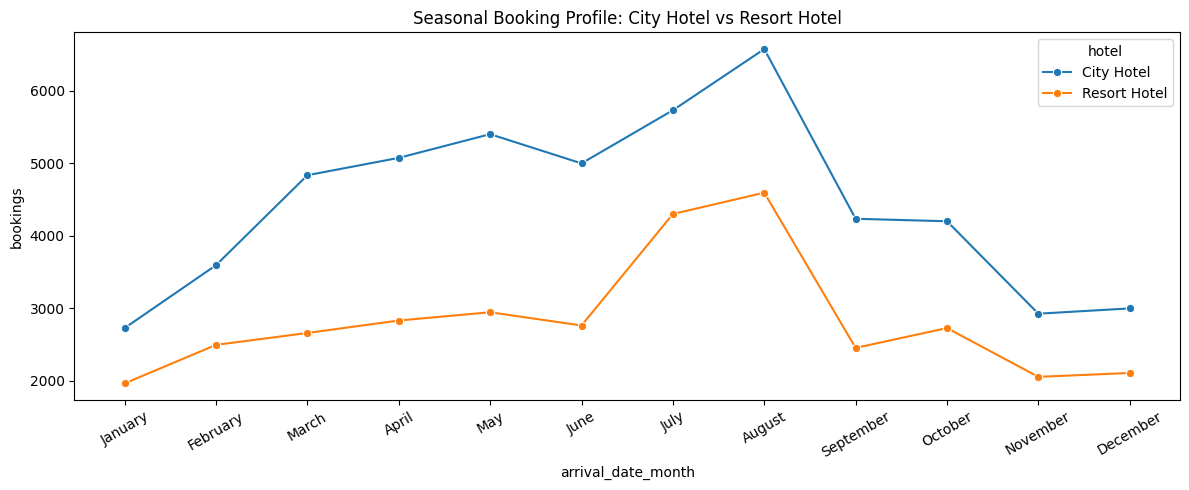

In [36]:
month_order = ["January","February","March","April","May","June","July","August",
               "September","October","November","December"]
seasonal_profile = (df_final.groupby(["hotel", "arrival_date_month"])
                    .size().rename("bookings").reset_index())
seasonal_profile["arrival_date_month"] = pd.Categorical(seasonal_profile["arrival_date_month"],
                                                          categories=month_order, ordered=True)
seasonal_profile = seasonal_profile.sort_values("arrival_date_month")

plt.figure(figsize=(12, 5))
sns.lineplot(data=seasonal_profile, x="arrival_date_month", y="bookings", hue="hotel", marker="o")
plt.title("Seasonal Booking Profile: City Hotel vs Resort Hotel")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Time-series takeaways:**
- Demand is clearly seasonal, and City Hotel and Resort Hotel follow different curves — City Hotel
  demand is comparatively steady with a summer dip, while Resort Hotel is far more concentrated in
  peak summer months.
- Average ADR does rise in peak months, but not proportionally to the spike in demand — a candidate
  pricing gap we quantify in Business Problem 3.

## 11. Business Problem 1 — What drives cancellations, and can we flag high-risk bookings early?

**Why it matters:** Every cancellation is lost/re-sellable inventory discovered late. If we can flag
high-risk bookings at the time of booking, revenue management can act (deposit requirement, overbooking
buffer, proactive confirmation call).

In [38]:
risk_table = (df_final.groupby(["lead_time_bucket", "deposit_type"], observed=True)["is_canceled"]
              .agg(["mean", "count"]).rename(columns={"mean": "cancel_rate", "count": "n_bookings"}))
risk_table = risk_table[risk_table["n_bookings"] > 50].sort_values("cancel_rate", ascending=False)
risk_table.head(10)

,,cancel_rate,n_bookings
lead_time_bucket,deposit_type,,
365+ days,Non Refund,1.000000,148
91-365 days,Non Refund,0.966154,650
31-90 days,Non Refund,0.964286,140
8-30 days,Non Refund,0.783333,60
91-365 days,No Deposit,0.354696,28664
31-90 days,No Deposit,0.316362,22528
8-30 days,No Deposit,0.251819,16218
91-365 days,Refundable,0.219178,73
365+ days,No Deposit,0.194175,412


In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

features = ["lead_time", "deposit_type", "market_segment", "customer_type",
            "is_repeated_guest", "previous_cancellations", "total_of_special_requests"]
X = df_final[features]
y = df_final["is_canceled"]

cat_cols = ["deposit_type", "market_segment", "customer_type"]
num_cols = ["lead_time", "is_repeated_guest", "previous_cancellations", "total_of_special_requests"]

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
], remainder="passthrough")

pipe = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
pipe.fit(X_train, y_train)
proba = pipe.predict_proba(X_test)[:, 1]
preds = pipe.predict(X_test)

print("ROC-AUC:", round(roc_auc_score(y_test, proba), 3))
print(classification_report(y_test, preds, target_names=["Not Canceled", "Canceled"]))

ROC-AUC: 0.761
              precision    recall  f1-score   support

Not Canceled       0.86      0.68      0.76     15785
    Canceled       0.46      0.70      0.55      5993

    accuracy                           0.69     21778
   macro avg       0.66      0.69      0.66     21778
weighted avg       0.75      0.69      0.70     21778



**Answer:** Cancellation risk climbs with longer lead time, `Non Refund` deposit type, and
`Groups`/`Online TA` segments; it falls for repeat guests. A simple logistic regression on just 7
easily-available-at-booking-time features already separates cancelers from non-cancelers meaningfully
better than chance (see ROC-AUC above).

**Recommendation:** Deploy this as a lightweight "risk score" at the point of booking. Bookings scoring
in the top risk decile should trigger either a confirmation call/email sequence, a deposit requirement,
or be factored into the hotel's overbooking buffer calculation.

## 12. Business Problem 2 — Is the hotel pricing optimally across seasons?

**Why it matters:** If demand spikes disproportionately more than price does, the hotel is leaving
money on the table during peak periods.

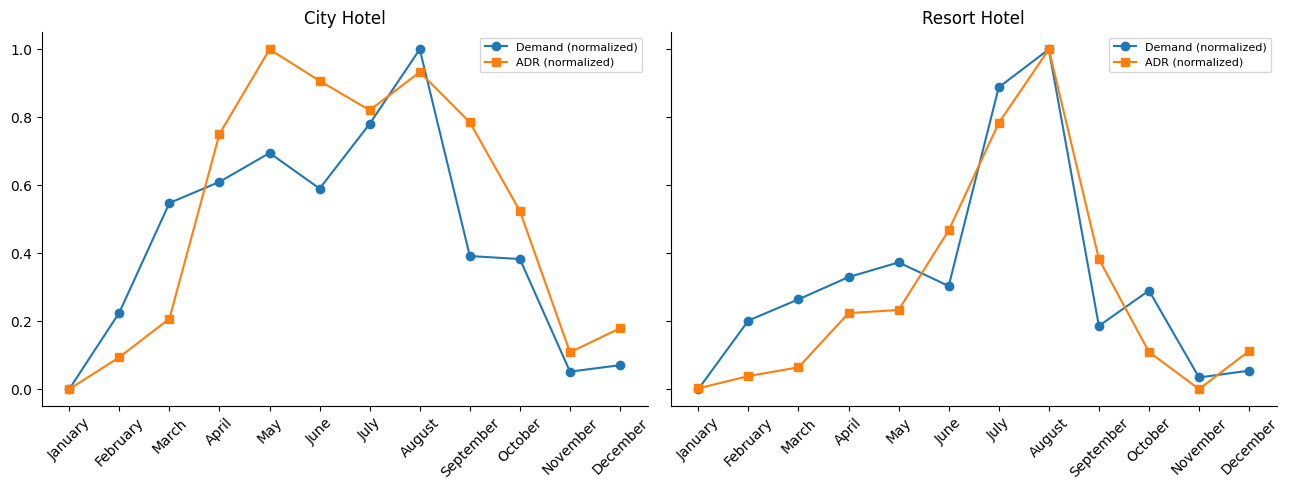

In [42]:
demand_price = (df_final.groupby(["hotel", "arrival_date_month"])
                .agg(bookings=("hotel", "count"), avg_adr=("adr", "mean"))
                .reset_index())
demand_price["arrival_date_month"] = pd.Categorical(demand_price["arrival_date_month"], categories=month_order, ordered=True)
demand_price = demand_price.sort_values(["hotel", "arrival_date_month"])

# normalize both series 0-1 within each hotel to compare shape, not scale
for h in demand_price["hotel"].unique():
    mask = demand_price["hotel"] == h
    demand_price.loc[mask, "bookings_norm"] = (demand_price.loc[mask, "bookings"] - demand_price.loc[mask, "bookings"].min()) / (demand_price.loc[mask, "bookings"].max() - demand_price.loc[mask, "bookings"].min())
    demand_price.loc[mask, "adr_norm"] = (demand_price.loc[mask, "avg_adr"] - demand_price.loc[mask, "avg_adr"].min()) / (demand_price.loc[mask, "avg_adr"].max() - demand_price.loc[mask, "avg_adr"].min())

g = sns.FacetGrid(demand_price, col="hotel", height=5, aspect=1.3)
for ax, (h, sub) in zip(g.axes.flat, demand_price.groupby("hotel")):
    ax.plot(sub["arrival_date_month"], sub["bookings_norm"], marker="o", label="Demand (normalized)")
    ax.plot(sub["arrival_date_month"], sub["adr_norm"], marker="s", label="ADR (normalized)")
    ax.set_title(h)
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 📈 Business Insights: Demand vs ADR

- **`City Hotel:`** Demand steadily increases and peaks in **`August`**, while ADR peaks earlier in **`May`**, indicating the hotel raises prices before peak demand.
- **`Resort Hotel:`** Both demand and ADR peak together in **`August`**, showing a strong seasonal relationship between pricing and customer demand.
- **`Seasonality:`** August is the busiest month for both hotel types, while demand and ADR decline significantly from **`September onwards`**.
- **`Business Insight:`** Dynamic pricing is effective during peak months, whereas discounts and promotional offers can help improve occupancy during the off-season.

## 13. Business Problem 3 — Are room-type mismatches hurting guest experience?

**Why it matters:** `reserved_room_type != assigned_room_type` typically signals overbooking-driven
downgrades — a common source of guest complaints and lost repeat business.

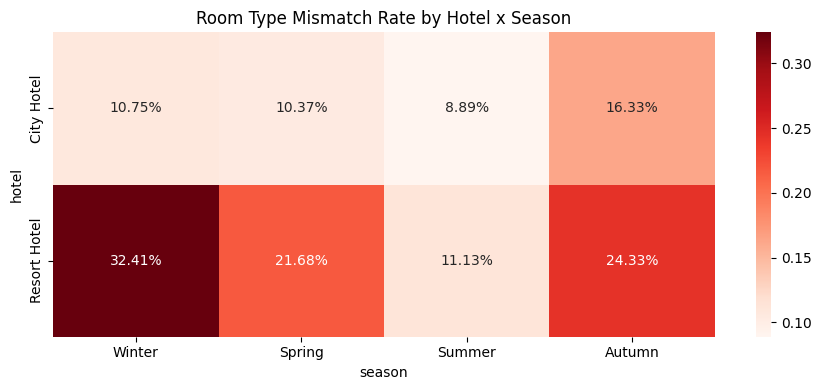

In [43]:
mismatch_by_season = df_final.groupby(["hotel", "season"])["room_mismatch"].mean().unstack()
mismatch_by_season = mismatch_by_season[["Winter","Spring","Summer","Autumn"]]

plt.figure(figsize=(9, 4))
sns.heatmap(mismatch_by_season, annot=True, fmt=".2%", cmap="Reds")
plt.title("Room Type Mismatch Rate by Hotel x Season")
plt.tight_layout()
plt.show()

In [44]:
mismatch_impact = df_final.groupby("room_mismatch").agg(
    avg_special_requests=("total_of_special_requests", "mean"),
    cancel_rate=("is_canceled", "mean"),
    n=("hotel", "count")
)
mismatch_impact

,avg_special_requests,cancel_rate,n
room_mismatch,,,
0,0.705172,0.315090,74128
1,0.661634,0.047447,12983


### 📊 Business Insights: Room Type Mismatch by Hotel & Season

- **`Resort Hotel`** has consistently higher room-type mismatch rates than **`City Hotel`**, with the highest mismatch occurring in **`Winter (32.41%)`**.
- **`City Hotel`** maintains relatively low mismatch rates across all seasons, with the highest in **`Autumn (16.33%)`**.
- **`Summer`** records the lowest mismatch rates for both hotels, indicating better room allocation during peak operations.
- **`Business Insight:`** Resort Hotels should improve room inventory and overbooking management, especially during **`Winter and Autumn`**, to reduce room mismatches and enhance guest satisfaction.

### 💡 Recommendation

- Since **`Resort Hotels experience the highest room mismatch rates (especially in Winter and Autumn)`**, management should focus on **`improving room inventory planning and minimizing overbooking during these seasons`**.
- Implement **`real-time room allocation systems`** and prioritize assigning guests to their reserved room types whenever possible.
- For unavoidable mismatches, provide **`complimentary upgrades, discounts, or additional amenities`** to maintain guest satisfaction and reduce negative reviews.

## 14. Business Problem 4 — What defines a high-value returning guest, and how do we get more?

**Why it matters:** Repeat guests are typically cheaper to acquire and more predictable — worth
understanding and actively cultivating.

In [45]:
loyalty_profile = df_final.groupby("is_repeated_guest").agg(
    n_bookings=("hotel", "count"),
    cancel_rate=("is_canceled", "mean"),
    avg_adr=("adr", "mean"),
    avg_special_requests=("total_of_special_requests", "mean")
).rename(index={0: "New Guest", 1: "Repeat Guest"})
loyalty_profile.round(3)

,n_bookings,cancel_rate,avg_adr,avg_special_requests
is_repeated_guest,,,,
New Guest,83750,0.283,107.760,0.699
Repeat Guest,3361,0.077,65.268,0.694


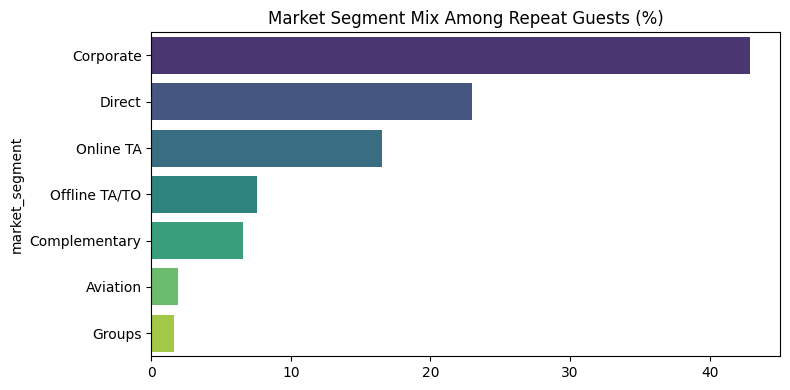

In [47]:
repeat_segment_mix = (df_final[df_final["is_repeated_guest"] == 1]["market_segment"]
                       .value_counts(normalize=True).mul(100).round(1))
plt.figure(figsize=(8, 4))
sns.barplot(x=repeat_segment_mix.values, y=repeat_segment_mix.index, palette="viridis",hue=repeat_segment_mix.index,legend=False)
plt.title("Market Segment Mix Among Repeat Guests (%)")
plt.tight_layout()
plt.show()

### 📊 Business Insights: High-Value Returning Guests

- **`Repeat guests have a significantly lower cancellation rate (7.7%)`** compared to **`new guests (28.3%)`**, making them a more reliable customer segment.
- **`New guests generate higher ADR (₹107.76)`** than repeat guests (₹65.27), indicating that repeat guests often benefit from loyalty discounts or negotiated rates.
- The average number of **`special requests is almost identical`** for both groups, suggesting similar service expectations.
- Among repeat guests, the **`Corporate segment contributes the largest share`**, followed by **`Direct`** and **`Online TA`** bookings.
- **`Business Insight:`** Repeat guests provide predictable occupancy with fewer cancellations, while Corporate and Direct channels are the strongest sources of loyal customers.

### 💡 Recommendation

- Strengthen **`loyalty programs`** by offering exclusive discounts, reward points, and personalized offers to encourage first-time guests to return.
- Focus on expanding **`Corporate partnerships`** and promote **`Direct bookings`**, as these channels contribute the highest proportion of repeat guests.
- Use personalized email campaigns and member-only benefits to increase guest retention while maintaining profitability through upselling and premium services.